In [2]:
%run ../setup.py
%load_ext autoreload
%autoreload 2
# ============= 
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
# ============= VISUALIZE AND CONFIG PARAMS =======
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (12, 8),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'lines.linewidth': 2,
    'grid.alpha': 0.3,
    'savefig.dpi': 300,
})
# ============= DATA RAW ==========================
from utils.data_loader import load_retail_data
# ============= TURN OFF THE WARNING ==============
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
df_raw = load_retail_data()
df = df_raw.copy()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [4]:
print("Số dòng, số cột:", df.shape)

df.info()

Số dòng, số cột: (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


Dữ liệu gồm 541,909 dòng và 8 cột, thể hiện các giao dịch bán lẻ trực tuyến theo từng dòng sản phẩm trong hóa đơn. Các cột chính bao gồm mã hóa đơn, mã sản phẩm, mô tả sản phẩm, số lượng, thời gian giao dịch, đơn giá, mã khách hàng và quốc gia.

Cột InvoiceDate đã ở dạng thời gian, thuận lợi cho việc phân tích theo ngày, tháng, giờ và chuỗi thời gian. Tuy nhiên, CustomerID có nhiều giá trị thiếu, vì vậy không nên xóa toàn bộ dữ liệu thiếu ngay từ đầu. Các dòng thiếu CustomerID vẫn có thể dùng cho phân tích doanh thu, sản phẩm và quốc gia.

Các cột cần thiết đều tồn tại trong dataset. Điều này xác nhận dữ liệu có đủ thông tin cơ bản để phân tích giao dịch, doanh thu, sản phẩm, khách hàng, quốc gia và thời gian

In [5]:
df.columns

expected_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country"
]

for col in expected_columns:
    print(col, ":", col in df.columns)

InvoiceNo : True
StockCode : True
Description : True
Quantity : True
InvoiceDate : True
UnitPrice : True
CustomerID : True
Country : True


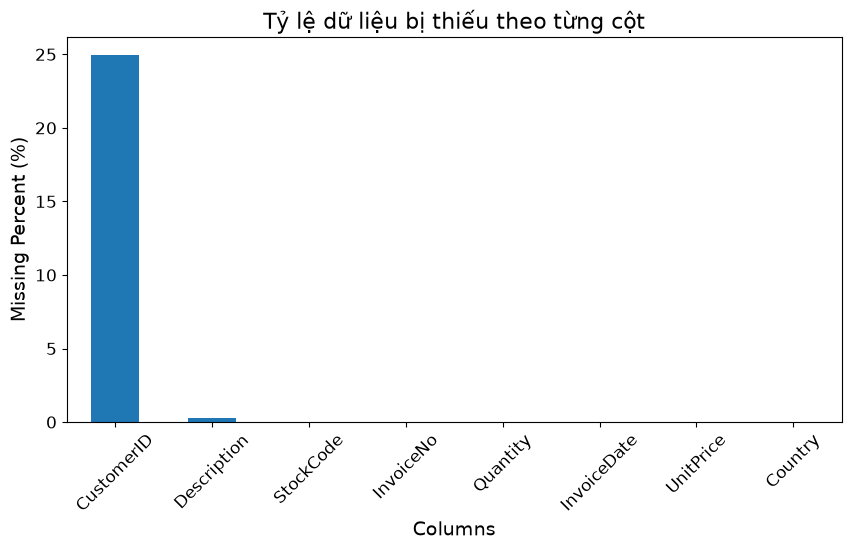

In [6]:
#Kiểm tra missing values
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values(by="missing_count", ascending=False)

missing_table


plt.figure(figsize=(10, 5))
missing_table["missing_percent"].plot(kind="bar")
plt.title("Tỷ lệ dữ liệu bị thiếu theo từng cột")
plt.ylabel("Missing Percent (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.show()

Dữ liệu có 5,268 dòng trùng lặp, chiếm khoảng 0.97% tổng số dòng. Tỷ lệ này không quá lớn nhưng vẫn cần xử lý, vì các dòng trùng lặp có thể làm sai lệch tổng số lượng bán, tổng giá trị đơn hàng và các thống kê mô tả.

Do mỗi dòng dữ liệu đại diện cho một dòng sản phẩm trong hóa đơn, việc giữ lại dòng trùng lặp có thể khiến doanh thu bị tính lặp. Vì vậy, nhóm tiến hành loại bỏ duplicate trước khi phân tích sâu hơn.

In [7]:
#Kiểm tra dòng trùng lặp
duplicate_count = df.duplicated().sum()
duplicate_percent = df.duplicated().mean() * 100

print("Số dòng trùng lặp:", duplicate_count)
print("Tỷ lệ dòng trùng lặp (%):", duplicate_percent)

df[df.duplicated()].head()

Số dòng trùng lặp: 5268
Tỷ lệ dòng trùng lặp (%): 0.9721189350979592


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,"17,908.00",United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,"17,908.00",United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,"17,908.00",United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,"17,908.00",United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,"17,920.00",United Kingdom


In [8]:
#Kiểm tra thống kê mô tả ban đầu
df.describe()



,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


Biến Quantity có giá trị nhỏ nhất âm và giá trị lớn nhất rất lớn, cho thấy dữ liệu tồn tại các giao dịch hủy, trả hàng hoặc điều chỉnh bất thường. Biến UnitPrice cũng có giá trị không hợp lệ hoặc ngoại lệ lớn.

Trung vị của Quantity, UnitPrice và giá trị lớn nhất chênh lệch rất mạnh, cho thấy dữ liệu bị lệch phải và có nhiều outlier. Vì vậy, khi trực quan hóa và xây dựng mô hình, cần kiểm tra outlier và cân nhắc biến đổi log cho biến doanh thu.

In [9]:
df.describe(include="object")

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


Dữ liệu có nhiều mã hóa đơn, mã sản phẩm và 38 quốc gia. Quốc gia xuất hiện nhiều nhất là United Kingdom, cho thấy dữ liệu bị mất cân bằng mạnh theo quốc gia.

In [10]:
#Kiểm tra dữ liệu bất thường
print("Số dòng Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Số dòng UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print("Số dòng CustomerID bị thiếu:", df["CustomerID"].isnull().sum())

df[df["Quantity"] <= 0].head()



Số dòng Quantity <= 0: 10624
Số dòng UnitPrice <= 0: 2517
Số dòng CustomerID bị thiếu: 135080


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,"14,527.00",United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom


Dữ liệu có 10,624 dòng Quantity <= 0, 2,517 dòng UnitPrice <= 0 và 135,080 dòng thiếu CustomerID. Các dòng Quantity <= 0 nhiều khả năng liên quan đến đơn hủy, trả hàng hoặc điều chỉnh giao dịch.

Các dòng UnitPrice <= 0 không phù hợp để tính doanh thu bán hàng thông thường. Do đó, cần tách dữ liệu gốc và dữ liệu bán hàng hợp lệ, thay vì xóa toàn bộ dữ liệu bất thường ngay từ đầu.

In [11]:
df[df["UnitPrice"] <= 0].head()



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom


Các dòng có UnitPrice <= 0 thường không đại diện cho giao dịch bán hàng thông thường. Một số dòng còn thiếu mô tả sản phẩm hoặc thiếu mã khách hàng.

In [12]:
#Tạo biến đánh dấu đơn hủy
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df["IsCancelled"] = df["InvoiceNo"].str.startswith("C")

df[["InvoiceNo", "Quantity", "UnitPrice", "IsCancelled"]].head()

,InvoiceNo,Quantity,UnitPrice,IsCancelled
0,536365,6,2.55,False
1,536365,6,3.39,False
2,536365,8,2.75,False
3,536365,6,3.39,False
4,536365,6,3.39,False


Biến IsCancelled được tạo dựa trên quy tắc mã hóa đơn bắt đầu bằng chữ C, thường biểu thị giao dịch hủy hoặc điều chỉnh. Đây là biến phục vụ bước làm sạch dữ liệu, không phải biến được tạo tùy ý để đưa ngay vào mô hình.

Biến này giúp nhóm nhận diện và tách các giao dịch hủy khỏi dữ liệu bán hàng hợp lệ.


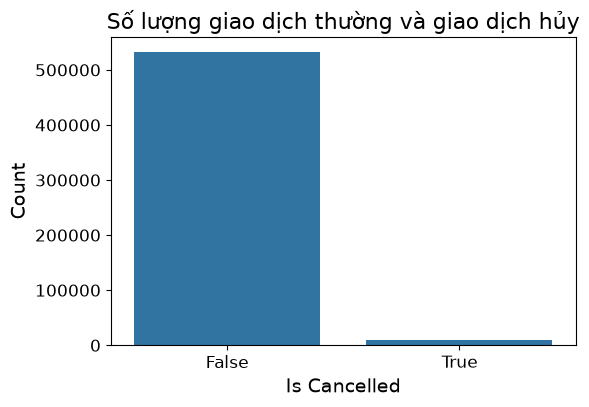

In [13]:
cancel_summary = df["IsCancelled"].value_counts().reset_index()
cancel_summary.columns = ["IsCancelled", "Count"]
cancel_summary

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="IsCancelled")
plt.title("Số lượng giao dịch thường và giao dịch hủy")
plt.xlabel("Is Cancelled")
plt.ylabel("Count")
plt.show()

Phần lớn giao dịch là giao dịch không hủy, trong khi giao dịch hủy chỉ chiếm một phần nhỏ. Tuy nhiên, các giao dịch hủy vẫn cần xử lý riêng vì thường đi kèm với Quantity âm và có thể làm sai lệch doanh thu nếu giữ chung với dữ liệu bán hàng hợp lệ.

In [14]:
df_clean = df.copy()

before = df_clean.shape[0]

df_clean = df_clean.drop_duplicates()

after = df_clean.shape[0]

print("Số dòng trước khi xóa duplicate:", before)
print("Số dòng sau khi xóa duplicate:", after)
print("Số dòng đã xóa:", before - after)

Số dòng trước khi xóa duplicate: 541909
Số dòng sau khi xóa duplicate: 536641
Số dòng đã xóa: 5268


In [15]:
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)
df_clean["StockCode"] = df_clean["StockCode"].astype(str)
df_clean["Description"] = df_clean["Description"].astype(str)
df_clean["Country"] = df_clean["Country"].astype(str)

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean.info()

<class 'pandas.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  str           
 1   StockCode    536641 non-null  str           
 2   Description  535187 non-null  str           
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[us]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      536641 non-null  str           
 8   IsCancelled  536641 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 37.4 MB


Các cột định danh như InvoiceNo, StockCode, Description và Country được chuyển sang dạng chuỗi để thuận tiện cho việc kiểm tra ký tự, tạo biến đánh dấu và nhóm dữ liệu. Cột InvoiceDate được chuyển sang kiểu thời gian để có thể trích xuất tháng, ngày, giờ và phục vụ phân tích chuỗi thời gian.

In [16]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Day"] = df_clean["InvoiceDate"].dt.day
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour
df_clean["Weekday"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Date"] = df_clean["InvoiceDate"].dt.date
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Year,Month,Day,Hour,Weekday,Date,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12


In [17]:
# Tạo các biến nghiệp vụ để nhận diện loại giao dịch

df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)
df_clean["StockCode"] = df_clean["StockCode"].astype(str)
df_clean["Description"] = df_clean["Description"].astype(str)

# Đơn hủy: InvoiceNo bắt đầu bằng C
df_clean["IsCancelled"] = df_clean["InvoiceNo"].str.startswith("C")

# Dòng discount: StockCode = D hoặc Description có chữ discount
df_clean["IsDiscount"] = (
    (df_clean["StockCode"].str.upper() == "D") |
    (df_clean["Description"].str.contains("discount", case=False, na=False))
)

# Doanh thu dòng giao dịch
df_clean["TotalOrder"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[[
    "InvoiceNo", "StockCode", "Description",
    "Quantity", "UnitPrice", "TotalOrder",
    "IsCancelled", "IsDiscount"
]].head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,TotalOrder,IsCancelled,IsDiscount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,False,False
1,536365,71053,WHITE METAL LANTERN,6,3.39,20.34,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,False,False


Biến IsDiscount được tạo để nhận diện các dòng chiết khấu, thường có StockCode = D hoặc mô tả chứa từ Discount. Các dòng này không đại diện cho giao dịch bán sản phẩm thông thường, nên cần được tách riêng trước khi phân tích doanh thu.

Biến TotalOrder được tính bằng Quantity * UnitPrice, thể hiện giá trị tiền của từng dòng giao dịch. Cần lưu ý rằng TotalOrder hiện tại là giá trị ở cấp dòng sản phẩm, chưa phải tổng giá trị của cả hóa đơn. Khi phân tích ở cấp hóa đơn, cần tổng hợp TotalOrder theo InvoiceNo để tạo InvoiceTotalOrder.

In [18]:
special_summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Cancelled rows",
        "Discount rows",
        "Quantity <= 0",
        "UnitPrice <= 0",
        "TotalOrder <= 0"
    ],
    "Count": [
        len(df_clean),
        df_clean["IsCancelled"].sum(),
        df_clean["IsDiscount"].sum(),
        (df_clean["Quantity"] <= 0).sum(),
        (df_clean["UnitPrice"] <= 0).sum(),
        (df_clean["TotalOrder"] <= 0).sum()
    ]
})

special_summary

,Metric,Count
0,Total rows,536641
1,Cancelled rows,9251
2,Discount rows,77
3,Quantity <= 0,10587
4,UnitPrice <= 0,2512
5,TotalOrder <= 0,11763


Sau khi loại bỏ duplicate, dữ liệu còn 536,641 dòng. Trong đó có 9,251 dòng đơn hủy, 77 dòng discount, 10,587 dòng có Quantity <= 0, 2,512 dòng có UnitPrice <= 0 và 11,763 dòng có TotalOrder <= 0.

Kết quả này cho thấy dữ liệu chứa nhiều giao dịch không phù hợp để xem là bán hàng hợp lệ. Vì vậy, cần tạo tập df_sales bằng cách loại đơn hủy, discount, Quantity không dương, UnitPrice không dương và TotalOrder không dương.

In [19]:
# Xem các dòng hủy hoặc discount
df_clean[
    (df_clean["IsCancelled"] == True) |
    (df_clean["IsDiscount"] == True)
][[
    "InvoiceNo", "StockCode", "Description",
    "Quantity", "UnitPrice", "TotalOrder",
    "CustomerID", "Country",
    "IsCancelled", "IsDiscount"
]].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,TotalOrder,CustomerID,Country,IsCancelled,IsDiscount
141,C536379,D,Discount,-1,27.50,-27.50,"14,527.00",United Kingdom,True,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,-4.65,"15,311.00",United Kingdom,True,False
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,-19.80,"17,548.00",United Kingdom,True,False
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,-6.96,"17,548.00",United Kingdom,True,False
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,-6.96,"17,548.00",United Kingdom,True,False
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,-6.96,"17,548.00",United Kingdom,True,False
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45,-41.40,"17,548.00",United Kingdom,True,False
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,-19.80,"17,548.00",United Kingdom,True,False
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65,-39.60,"17,548.00",United Kingdom,True,False
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25,-25.50,"17,897.00",United Kingdom,True,False


Các dòng được hiển thị cho thấy nhiều hóa đơn có mã bắt đầu bằng C đi kèm với Quantity âm. Ngoài ra, dòng có StockCode = D và mô tả Discount cho thấy đây là dòng chiết khấu hoặc điều chỉnh, không phải sản phẩm bán thông thường.

Do đó, việc tạo biến IsCancelled và IsDiscount là có cơ sở nghiệp vụ, phục vụ cho bước làm sạch dữ liệu trước khi phân tích doanh thu và xây dựng mô hình.

In [20]:
# Kiểm tra quan hệ giữa đơn hủy và Quantity âm
pd.crosstab(df_clean["IsCancelled"], df_clean["Quantity"] <= 0)

Quantity,False,True
IsCancelled,,
False,526054,1336
True,0,9251


Bảng chéo cho thấy toàn bộ 9,251 dòng có IsCancelled = True đều nằm trong nhóm Quantity <= 0. Điều này củng cố giả định rằng hóa đơn bắt đầu bằng chữ C là giao dịch hủy hoặc điều chỉnh.

Tuy nhiên, vẫn còn 1,336 dòng không bị đánh dấu hủy nhưng có Quantity <= 0. Vì vậy, không nên chỉ dựa vào IsCancelled, mà cần kết hợp thêm điều kiện Quantity > 0, UnitPrice > 0 và TotalOrder > 0 khi tạo tập dữ liệu bán hàng hợp lệ.

In [21]:
# Tách các nhóm dữ liệu để phân tích rõ ràng

df_cancelled = df_clean[df_clean["IsCancelled"] == True].copy()

df_discount = df_clean[df_clean["IsDiscount"] == True].copy()

df_sales = df_clean[
    (df_clean["IsCancelled"] == False) &
    (df_clean["IsDiscount"] == False) &
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0) &
    (df_clean["TotalOrder"] > 0)
].copy()

print("Số dòng df_clean:", df_clean.shape[0])
print("Số dòng đơn hủy:", df_cancelled.shape[0])
print("Số dòng discount:", df_discount.shape[0])
print("Số dòng bán hàng hợp lệ df_sales:", df_sales.shape[0])
print("Số dòng bị loại:", df_clean.shape[0] - df_sales.shape[0])

Số dòng df_clean: 536641
Số dòng đơn hủy: 9251
Số dòng discount: 77
Số dòng bán hàng hợp lệ df_sales: 524878
Số dòng bị loại: 11763


Tập df_sales được tạo để đại diện cho các giao dịch bán hàng hợp lệ. Các dòng đơn hủy, discount, Quantity không dương, UnitPrice không dương và TotalOrder không dương được loại khỏi tập này.

Sau khi lọc, dữ liệu bán hàng hợp lệ còn 524,878 dòng. Việc tách df_sales giúp đảm bảo các phân tích về doanh thu, sản phẩm bán chạy, quốc gia và mô hình hồi quy doanh thu không bị ảnh hưởng bởi các giao dịch hủy hoặc điều chỉnh kế toán.

In [22]:
print("Cancelled còn lại:", df_sales["IsCancelled"].sum())
print("Discount còn lại:", df_sales["IsDiscount"].sum())
print("Quantity <= 0 còn lại:", (df_sales["Quantity"] <= 0).sum())
print("UnitPrice <= 0 còn lại:", (df_sales["UnitPrice"] <= 0).sum())
print("TotalOrder <= 0 còn lại:", (df_sales["TotalOrder"] <= 0).sum())
print("Missing CustomerID còn lại:", df_sales["CustomerID"].isnull().sum())


df_sales.head()

Cancelled còn lại: 0
Discount còn lại: 0
Quantity <= 0 còn lại: 0
UnitPrice <= 0 còn lại: 0
TotalOrder <= 0 còn lại: 0
Missing CustomerID còn lại: 132186


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Year,Month,Day,Hour,Weekday,Date,YearMonth,IsDiscount,TotalOrder
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,False,2010,12,1,8,Wednesday,2010-12-01,2010-12,False,20.34


Sau khi tạo df_sales, các dòng đơn hủy, discount, Quantity không dương, UnitPrice không dương và TotalOrder không dương đều đã được loại bỏ. Điều này cho thấy điều kiện lọc dữ liệu bán hàng hợp lệ đã hoạt động đúng.

Tuy nhiên, df_sales vẫn còn 132,186 dòng thiếu CustomerID. Các dòng này vẫn có thể dùng cho EDA doanh thu, sản phẩm và quốc gia, nhưng không nên dùng cho phân tích cấp khách hàng như RFM hoặc mô hình dự báo khách hàng quay lại mua hàng.

In [23]:
#Tổng quan dữ liệu bán hàng hợp lệ
sales_overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Invoices",
        "Products",
        "Customers",
        "Countries",
        "Total Quantity",
        "Total Sales Amount",
        "Start Date",
        "End Date"
    ],
    "Value": [
        df_sales.shape[0],
        df_sales.shape[1],
        df_sales["InvoiceNo"].nunique(),
        df_sales["StockCode"].nunique(),
        df_sales["CustomerID"].nunique(),
        df_sales["Country"].nunique(),
        df_sales["Quantity"].sum(),
        df_sales["TotalOrder"].sum(),
        df_sales["InvoiceDate"].min(),
        df_sales["InvoiceDate"].max()
    ]
})

sales_overview

,Metric,Value
0,Rows,524878
1,Columns,18
2,Invoices,19960
3,Products,3922
4,Customers,4338
5,Countries,38
6,Total Quantity,5572420
7,Total Sales Amount,"10,642,110.80"
8,Start Date,2010-12-01 08:26:00
9,End Date,2011-12-09 12:50:00


Tập dữ liệu bán hàng hợp lệ gồm 524,878 dòng, 19,960 hóa đơn, 3,922 sản phẩm, 4,338 khách hàng và 38 quốc gia. Tổng giá trị bán hàng sau xử lý là khoảng 10.64 triệu.

Dữ liệu trải dài từ ngày 01/12/2010 đến 09/12/2011, phù hợp để phân tích xu hướng doanh thu theo tháng và có thể mở rộng sang phân tích chuỗi thời gian.

In [24]:
#Thống kê mô tả sau xử lý
df_sales[["Quantity", "UnitPrice", "TotalOrder"]].describe()

,Quantity,UnitPrice,TotalOrder
count,"524,878.00","524,878.00","524,878.00"
mean,10.62,3.92,20.28
std,156.28,36.09,271.69
min,1.00,0.00,0.00
25%,1.00,1.25,3.90
50%,4.00,2.08,9.92
75%,11.00,4.13,17.70
max,"80,995.00","13,541.33","168,469.60"


Sau khi lọc dữ liệu bán hàng hợp lệ, các biến Quantity, UnitPrice và TotalOrder đều có giá trị dương. Tuy nhiên, giá trị lớn nhất của các biến này vẫn rất cao so với trung vị, cho thấy dữ liệu vẫn có outlier mạnh.

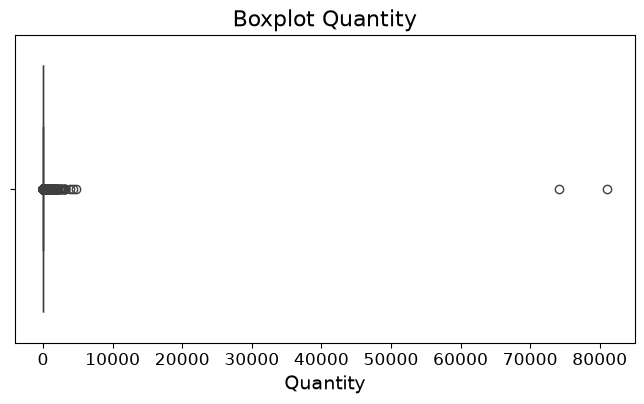

In [25]:
#Kiểm tra outlier bằng boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_sales["Quantity"])
plt.title("Boxplot Quantity")
plt.show()

Boxplot cho thấy Quantity có nhiều giá trị ngoại lệ rất lớn. Phần lớn giao dịch có số lượng nhỏ, trong khi một số giao dịch có số lượng cực cao.

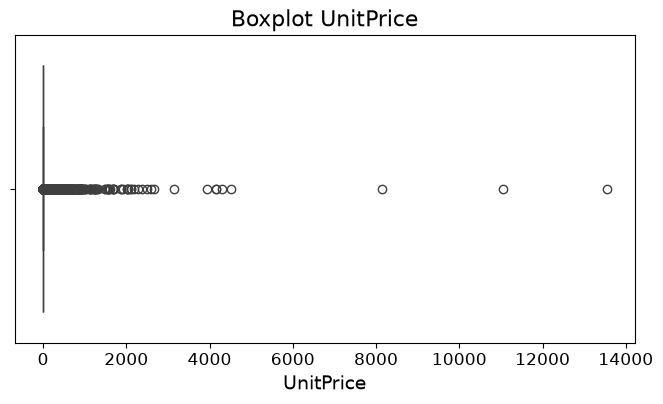

In [26]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_sales["UnitPrice"])
plt.title("Boxplot UnitPrice")
plt.show()

UnitPrice cũng có nhiều outlier, cho thấy một số sản phẩm hoặc dòng giao dịch có đơn giá rất cao so với phần lớn dữ liệu.

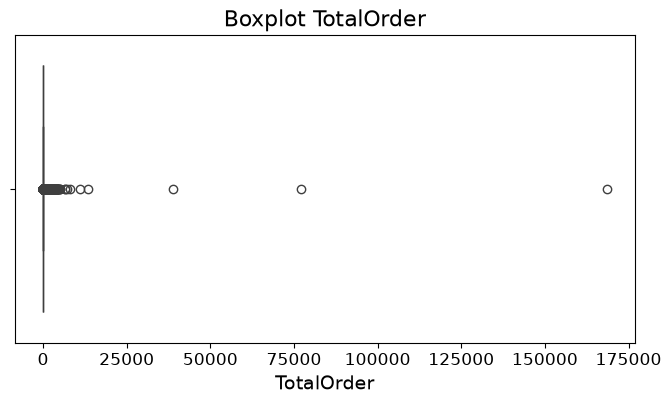

In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_sales["TotalOrder"])
plt.title("Boxplot TotalOrder")
plt.show()

TotalOrder bị lệch phải mạnh và có nhiều ngoại lệ. Điều này cho thấy phần lớn dòng giao dịch có giá trị nhỏ, nhưng tồn tại một số dòng có giá trị rất lớn

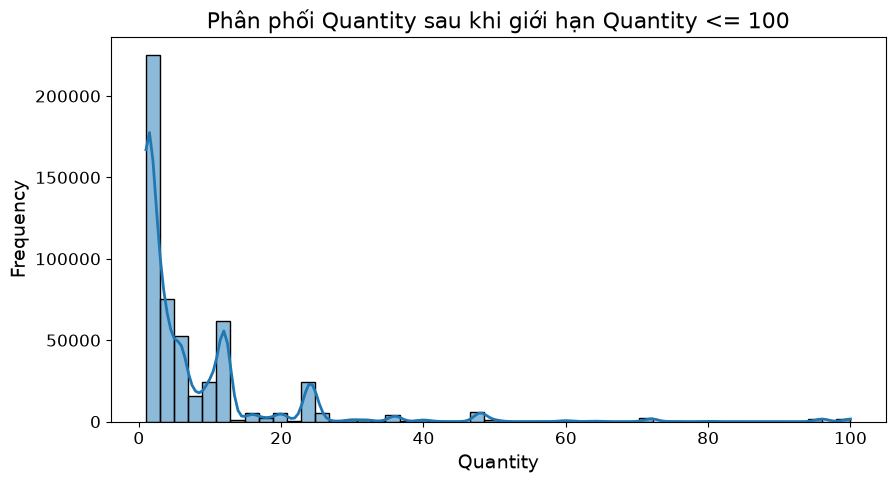

In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(df_sales[df_sales["Quantity"] <= 100]["Quantity"], bins=50, kde=True)
plt.title("Phân phối Quantity sau khi giới hạn Quantity <= 100")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

Sau khi giới hạn Quantity <= 100, phân phối dễ quan sát hơn. Phần lớn giao dịch tập trung ở mức số lượng nhỏ.

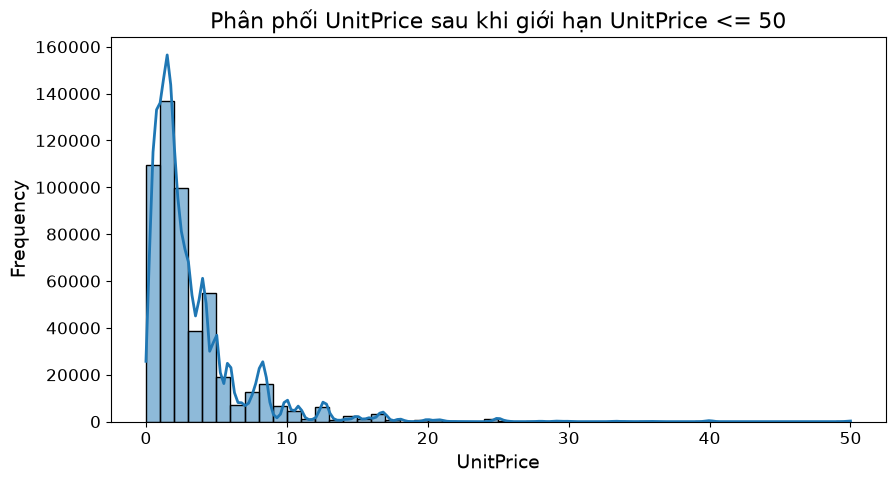

In [29]:
plt.figure(figsize=(10, 5))
sns.histplot(df_sales[df_sales["UnitPrice"] <= 50]["UnitPrice"], bins=50, kde=True)
plt.title("Phân phối UnitPrice sau khi giới hạn UnitPrice <= 50")
plt.xlabel("UnitPrice")
plt.ylabel("Frequency")
plt.show()

Sau khi giới hạn UnitPrice <= 50, có thể thấy phần lớn sản phẩm có đơn giá thấp. Điều này phù hợp với đặc điểm dữ liệu bán lẻ, nơi nhiều mặt hàng có giá trị nhỏ.

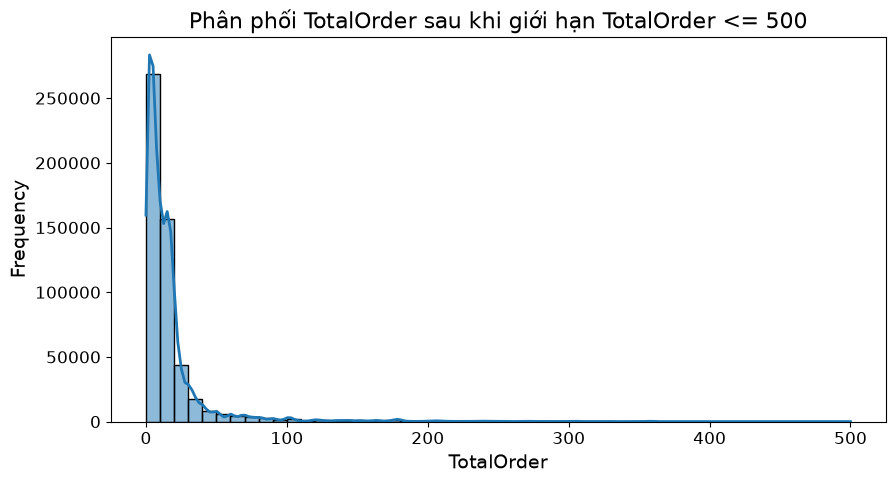

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(df_sales[df_sales["TotalOrder"] <= 500]["TotalOrder"], bins=50, kde=True)
plt.title("Phân phối TotalOrder sau khi giới hạn TotalOrder <= 500")
plt.xlabel("TotalOrder")
plt.ylabel("Frequency")
plt.show()

Sau khi giới hạn TotalOrder <= 500, phân phối cho thấy phần lớn dòng giao dịch có giá trị thấp. Dữ liệu có phân phối lệch phải, nên các mô hình tuyến tính có thể gặp vấn đề nếu dùng biến doanh thu gốc.

,YearMonth,TotalOrder
0,2010-12,"821,452.73"
1,2011-01,"689,811.61"
2,2011-02,"522,545.56"
3,2011-03,"716,215.26"
4,2011-04,"536,968.49"
5,2011-05,"769,296.61"
6,2011-06,"760,547.01"
7,2011-07,"718,076.12"
8,2011-08,"757,841.38"
9,2011-09,"1,056,435.19"


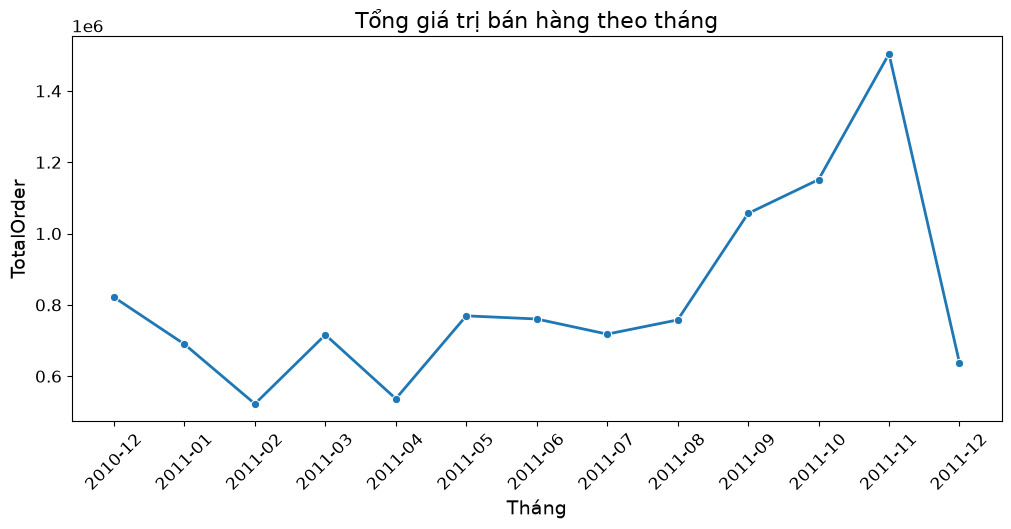

In [31]:
#Doanh thu theo tháng
monthly_sales = (
    df_sales.groupby("YearMonth")["TotalOrder"]
    .sum()
    .reset_index()
)

display(monthly_sales)


plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="YearMonth", y="TotalOrder", marker="o")
plt.title("Tổng giá trị bán hàng theo tháng")
plt.xlabel("Tháng")
plt.ylabel("TotalOrder")
plt.xticks(rotation=45)
plt.show()

Tổng giá trị bán hàng có xu hướng tăng mạnh ở các tháng cuối năm, đặc biệt là tháng 9, 10 và 11. Điều này cho thấy doanh thu có thể có yếu tố mùa vụ hoặc ảnh hưởng bởi nhu cầu mua sắm cuối năm.

,YearMonth,NumberOfOrders
0,2010-12,1559
1,2011-01,1086
2,2011-02,1100
3,2011-03,1454
4,2011-04,1246
5,2011-05,1681
6,2011-06,1533
7,2011-07,1475
8,2011-08,1361
9,2011-09,1837


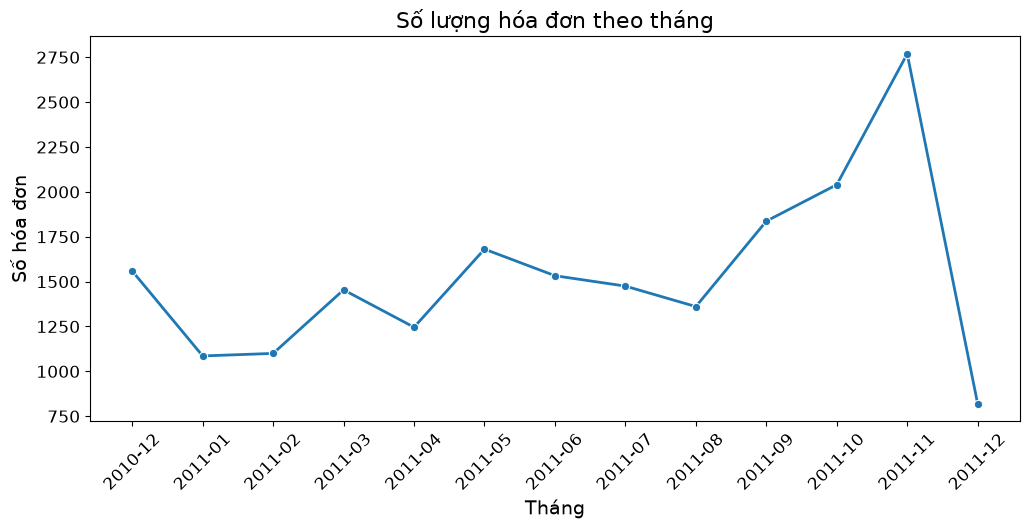

In [32]:
#Số lượng hóa đơn theo tháng
monthly_orders = (
    df_sales.groupby("YearMonth")["InvoiceNo"]
    .nunique()
    .reset_index()
)

monthly_orders.columns = ["YearMonth", "NumberOfOrders"]

display(monthly_orders)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_orders, x="YearMonth", y="NumberOfOrders", marker="o")
plt.title("Số lượng hóa đơn theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Số hóa đơn")
plt.xticks(rotation=45)
plt.show()

Số lượng hóa đơn theo tháng giúp kiểm tra liệu sự tăng doanh thu đến từ việc có nhiều đơn hàng hơn hay từ giá trị trung bình mỗi đơn hàng cao hơn.

Nếu doanh thu tăng cùng với số lượng hóa đơn, nguyên nhân có thể đến từ nhu cầu mua hàng tăng. Nếu doanh thu tăng nhưng số lượng hóa đơn không tăng tương ứng, nguyên nhân có thể đến từ giá trị đơn hàng lớn hơn.

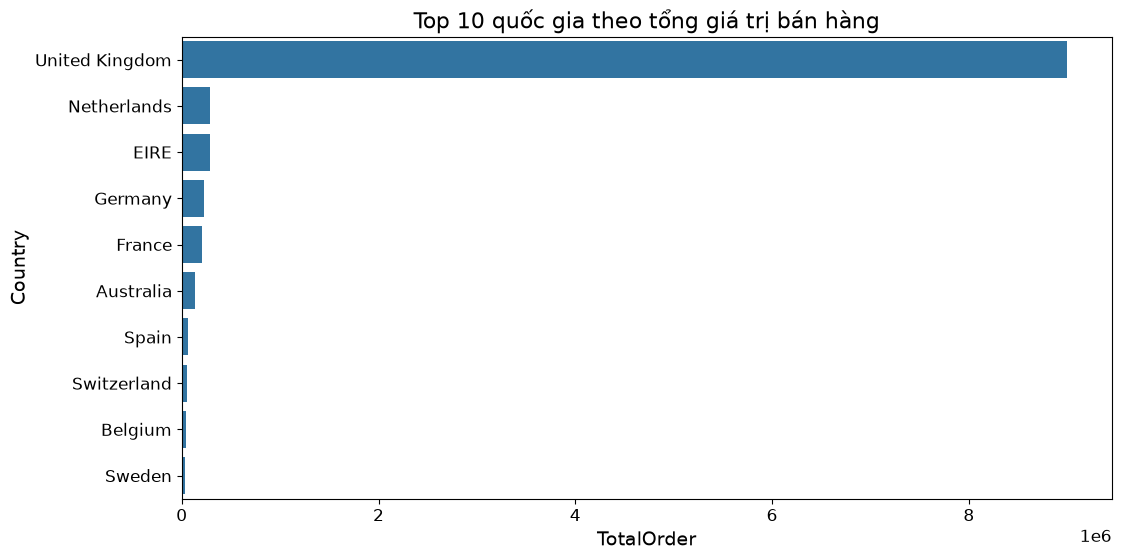

In [33]:
#Top quốc gia theo TotalOrder
country_sales = (
    df_sales.groupby("Country")["TotalOrder"]
    .agg(["count", "sum", "mean", "median"])
    .sort_values(by="sum", ascending=False)
    .reset_index()
)

country_sales.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_sales.head(10), x="sum", y="Country")
plt.title("Top 10 quốc gia theo tổng giá trị bán hàng")
plt.xlabel("TotalOrder")
plt.ylabel("Country")
plt.show()

United Kingdom chiếm tỷ trọng doanh thu vượt trội so với các quốc gia khác. Điều này cho thấy dữ liệu bị mất cân bằng mạnh theo quốc gia và kết quả phân tích tổng thể có thể bị chi phối bởi thị trường UK.

Không nên kết luận ngay rằng UK “ảnh hưởng” đến doanh thu. Nếu muốn đưa quốc gia vào mô hình, cần kiểm định thêm bằng mô hình hồi quy, biến dummy hoặc so sánh mô hình có và không có biến quốc gia.

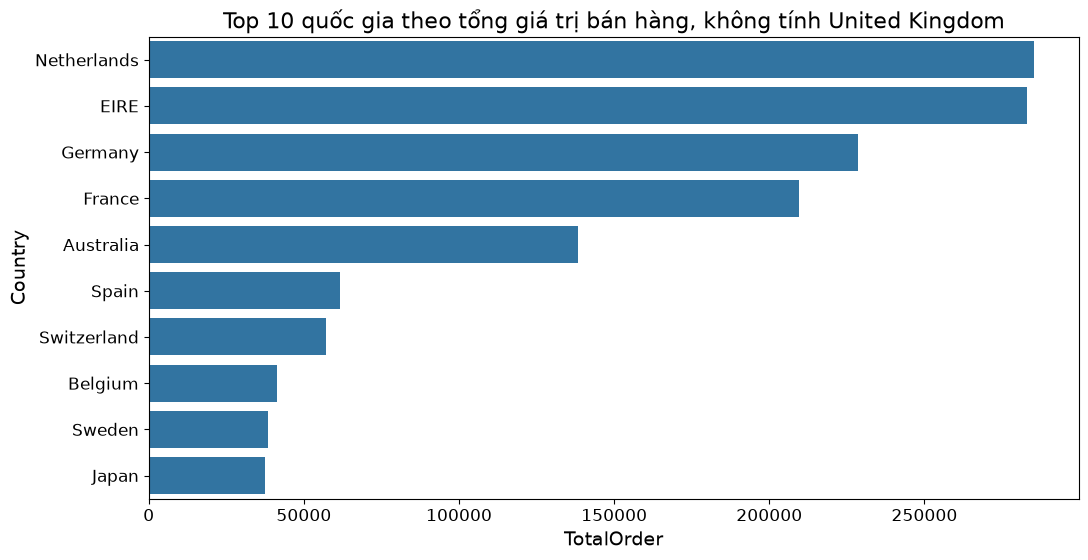

In [34]:
country_sales_without_uk = country_sales[country_sales["Country"] != "United Kingdom"]

plt.figure(figsize=(12, 6))
sns.barplot(data=country_sales_without_uk.head(10), x="sum", y="Country")
plt.title("Top 10 quốc gia theo tổng giá trị bán hàng, không tính United Kingdom")
plt.xlabel("TotalOrder")
plt.ylabel("Country")
plt.show()

Khi loại United Kingdom khỏi biểu đồ, có thể quan sát rõ hơn sự khác biệt giữa các quốc gia còn lại như Netherlands, EIRE, Germany và France.

Biểu đồ này cần thiết vì UK quá lớn, làm che khuất cấu trúc của các thị trường còn lại.

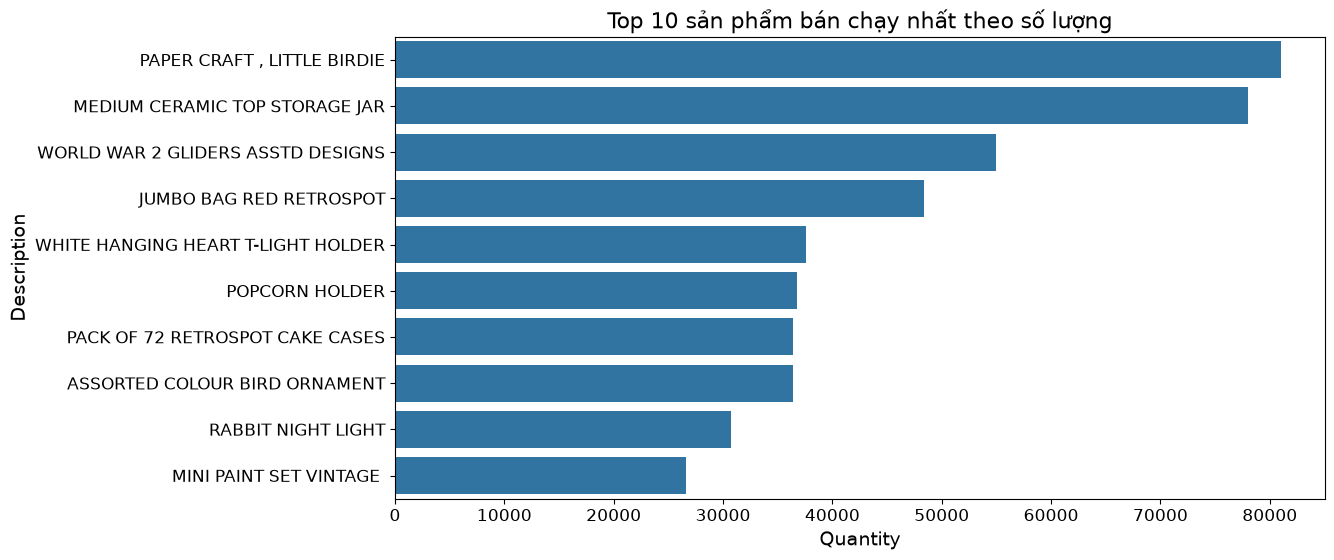

In [35]:
#Top sản phẩm theo số lượng bán
top_products_quantity = (
    df_sales.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_products_quantity.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_products_quantity.head(10),
    x="Quantity",
    y="Description"
)
plt.title("Top 10 sản phẩm bán chạy nhất theo số lượng")
plt.xlabel("Quantity")
plt.ylabel("Description")
plt.show()

Biểu đồ cho biết các sản phẩm được bán nhiều nhất theo số lượng. Đây là góc nhìn về mức độ phổ biến của sản phẩm, nhưng không phản ánh trực tiếp đóng góp doanh thu.

Một sản phẩm có số lượng bán cao chưa chắc có doanh thu cao nếu đơn giá thấp. Vì vậy, cần phân tích thêm top sản phẩm theo TotalOrder.

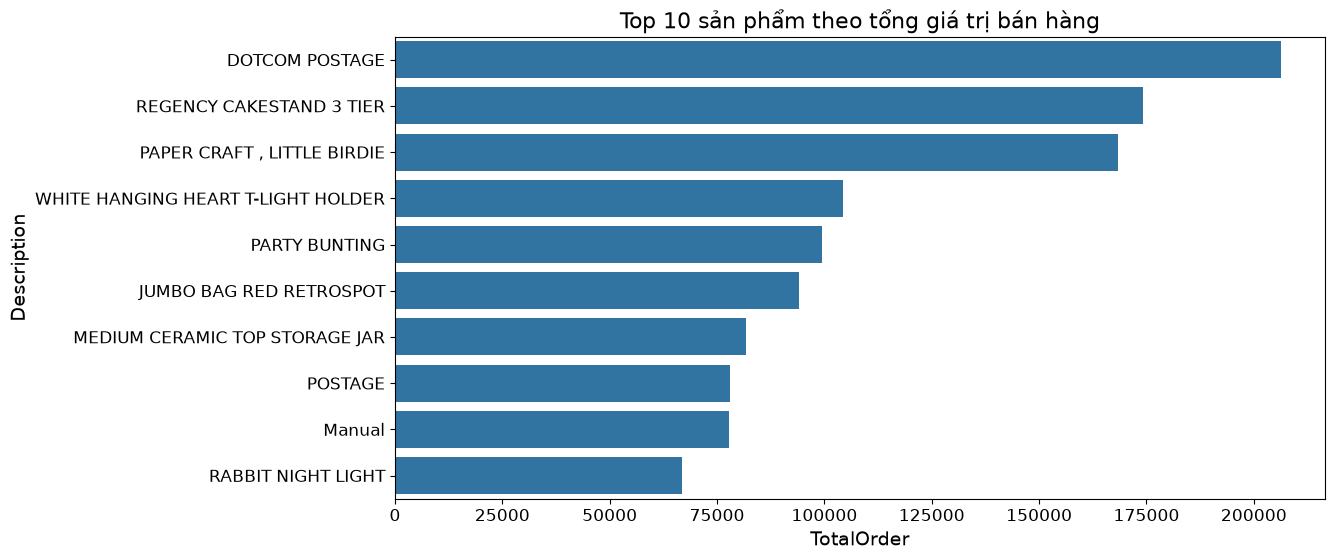

In [36]:
#Top sản phẩm theo TotalOrder
top_products_sales = (
    df_sales.groupby(["StockCode", "Description"])["TotalOrder"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_products_sales.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_products_sales.head(10),
    x="TotalOrder",
    y="Description"
)
plt.title("Top 10 sản phẩm theo tổng giá trị bán hàng")
plt.xlabel("TotalOrder")
plt.ylabel("Description")
plt.show()

Biểu đồ cho biết các sản phẩm đóng góp nhiều nhất vào tổng giá trị bán hàng. Đây là góc nhìn quan trọng hơn khi mục tiêu là phân tích doanh thu.

Việc so sánh top sản phẩm theo số lượng và theo giá trị bán hàng giúp phân biệt sản phẩm bán chạy với sản phẩm tạo doanh thu cao.

In [37]:
#Tạo df_invoice
df_invoice = (
    df_sales.groupby("InvoiceNo")
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        CustomerID=("CustomerID", "first"),
        Country=("Country", "first"),
        InvoiceTotalOrder=("TotalOrder", "sum"),
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        NumberOfRows=("StockCode", "count"),
        AvgUnitPrice=("UnitPrice", "mean")
    )
    .reset_index()
)

df_invoice["Month"] = df_invoice["InvoiceDate"].dt.month
df_invoice["Hour"] = df_invoice["InvoiceDate"].dt.hour
df_invoice["Weekday"] = df_invoice["InvoiceDate"].dt.day_name()
df_invoice["IsWeekend"] = df_invoice["InvoiceDate"].dt.weekday.isin([5, 6]).astype(int)

df_invoice.head()

,InvoiceNo,InvoiceDate,CustomerID,Country,InvoiceTotalOrder,TotalQuantity,UniqueProducts,NumberOfRows,AvgUnitPrice,Month,Hour,Weekday,IsWeekend
0,536365,2010-12-01 08:26:00,"17,850.00",United Kingdom,139.12,40,7,7,3.91,12,8,Wednesday,0
1,536366,2010-12-01 08:28:00,"17,850.00",United Kingdom,22.20,12,2,2,1.85,12,8,Wednesday,0
2,536367,2010-12-01 08:34:00,"13,047.00",United Kingdom,278.73,83,12,12,4.85,12,8,Wednesday,0
3,536368,2010-12-01 08:34:00,"13,047.00",United Kingdom,70.05,15,4,4,4.78,12,8,Wednesday,0
4,536369,2010-12-01 08:35:00,"13,047.00",United Kingdom,17.85,3,1,1,5.95,12,8,Wednesday,0


df_invoice được tạo bằng cách tổng hợp dữ liệu bán hàng hợp lệ theo từng InvoiceNo. Đây là bước quan trọng vì mỗi hóa đơn có thể gồm nhiều dòng sản phẩm, trong khi bài toán hồi quy doanh thu nên được thực hiện ở cấp hóa đơn thay vì cấp dòng sản phẩm.

Biến InvoiceTotalOrder là tổng giá trị của toàn bộ hóa đơn và có thể được sử dụng làm biến mục tiêu cho hồi quy tuyến tính. Các biến như TotalQuantity, UniqueProducts, NumberOfRows, AvgUnitPrice, Month, Hour, Weekday và IsWeekend là các biến ứng viên cần được kiểm định trước khi đưa vào mô hình cuối.

In [38]:
df_invoice.describe()

,InvoiceDate,CustomerID,InvoiceTotalOrder,TotalQuantity,UniqueProducts,NumberOfRows,AvgUnitPrice,Month,Hour,IsWeekend
count,19960,"18,532.00","19,960.00","19,960.00","19,960.00","19,960.00","19,960.00","19,960.00","19,960.00","19,960.00"
mean,2011-06-29 09:26:50.380761,"15,266.38",533.17,279.18,26.03,26.30,8.73,7.38,12.59,0.11
min,2010-12-01 08:26:00,"12,346.00",0.38,1.00,1.00,1.00,0.06,1.00,6.00,0.00
25%,2011-03-28 15:46:30,"13,776.25",151.70,69.00,6.00,6.00,2.04,5.00,11.00,0.00
50%,2011-07-07 15:44:30,"15,178.50",303.30,150.00,15.00,15.00,2.87,8.00,12.00,0.00
75%,2011-10-11 09:20:00,"16,779.00",493.46,296.00,29.00,29.00,4.15,11.00,14.00,0.00
max,2011-12-09 12:50:00,"18,287.00","168,469.60","80,995.00","1,110.00","1,114.00","13,541.33",12.00,20.00,1.00
std,NaN,"1,734.12","1,780.41",955.01,46.98,47.29,159.11,3.45,2.40,0.31


Bảng thống kê ở cấp hóa đơn cho thấy InvoiceTotalOrder có giá trị trung bình cao hơn trung vị, chứng tỏ doanh thu hóa đơn bị lệch phải và có outlier.

Đây là cơ sở để cân nhắc sử dụng log1p(InvoiceTotalOrder) khi xây dựng mô hình hồi quy tuyến tính, nhằm giảm ảnh hưởng của các hóa đơn có giá trị quá lớn.

In [39]:
print("Số hóa đơn:", df_invoice["InvoiceNo"].nunique())
print("Số khách hàng:", df_invoice["CustomerID"].nunique())
print("Tổng InvoiceTotalOrder:", df_invoice["InvoiceTotalOrder"].sum())
print("Tổng TotalOrder từ df_sales:", df_sales["TotalOrder"].sum())

df_invoice["InvoiceTotalOrder"].sum()
df_sales["TotalOrder"].sum()

Số hóa đơn: 19960
Số khách hàng: 4338
Tổng InvoiceTotalOrder: 10642110.804
Tổng TotalOrder từ df_sales: 10642110.804000001


np.float64(10642110.804000001)

Tổng InvoiceTotalOrder trong df_invoice bằng tổng TotalOrder trong df_sales, cho thấy quá trình tổng hợp từ cấp dòng sản phẩm lên cấp hóa đơn là chính xác.

Đây là bước kiểm tra quan trọng trước khi sử dụng df_invoice cho hồi quy tuyến tính, vì nếu tổng bị lệch thì quá trình groupby có thể đã sai.

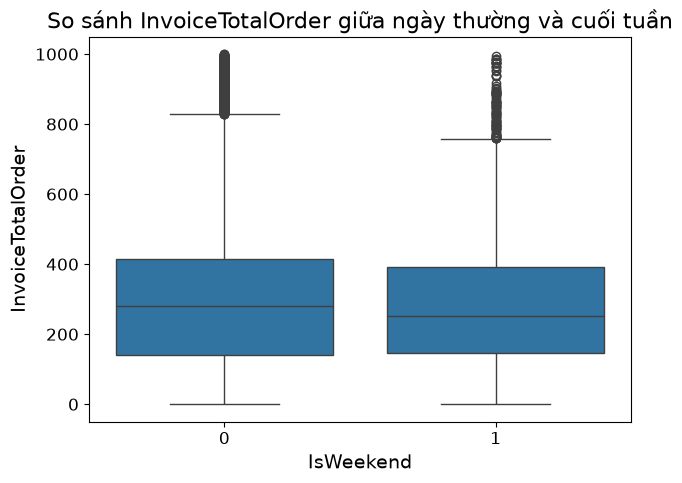

In [40]:
#Kiểm tra biến IsWeekend
weekend_summary = (
    df_invoice.groupby("IsWeekend")["InvoiceTotalOrder"]
    .agg(["count", "mean", "median", "std", "sum"])
)

weekend_summary

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_invoice[df_invoice["InvoiceTotalOrder"] <= 1000],
    x="IsWeekend",
    y="InvoiceTotalOrder"
)
plt.title("So sánh InvoiceTotalOrder giữa ngày thường và cuối tuần")
plt.xlabel("IsWeekend")
plt.ylabel("InvoiceTotalOrder")
plt.show()

Kết quả so sánh cho thấy hóa đơn ngày thường và cuối tuần có sự khác biệt về giá trị đơn hàng. Tuy nhiên, cần lưu ý rằng dữ liệu không có giao dịch vào Saturday, nên biến IsWeekend trong dataset này thực chất chủ yếu phản ánh Sunday so với các ngày còn lại.

Vì vậy, không nên diễn giải quá rộng rằng “cuối tuần ảnh hưởng đến doanh thu”. Biến này chỉ nên được xem là biến ứng viên và cần được kiểm tra tiếp trong mô hình hồi quy đa biến.

In [41]:
from scipy.stats import ttest_ind

normal_day = df_invoice[df_invoice["IsWeekend"] == 0]["InvoiceTotalOrder"]
weekend_day = df_invoice[df_invoice["IsWeekend"] == 1]["InvoiceTotalOrder"]

t_stat, p_value = ttest_ind(
    normal_day,
    weekend_day,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Có sự khác biệt có ý nghĩa thống kê giữa ngày thường và cuối tuần.")
else:
    print("Chưa đủ bằng chứng để kết luận có sự khác biệt giữa ngày thường và cuối tuần.")

t-statistic: 10.338346913247497
p-value: 6.176715593582869e-25
Có sự khác biệt có ý nghĩa thống kê giữa ngày thường và cuối tuần.


,count,mean,median,std,sum
Weekday,,,,,
Monday,"3,126.00",568.07,306.03,"1,630.79","1,775,782.07"
Tuesday,"3,554.00",612.18,310.78,"1,866.64","2,175,700.51"
Wednesday,"3,690.00",500.56,304.38,942.79,"1,847,074.38"
Thursday,"4,246.00",517.97,302.12,"1,157.46","2,199,292.57"
Friday,"3,140.00",585.18,306.00,"3,235.97","1,837,470.49"
Saturday,NaN,NaN,NaN,NaN,NaN
Sunday,"2,204.00",366.06,262.78,538.86,"806,790.78"


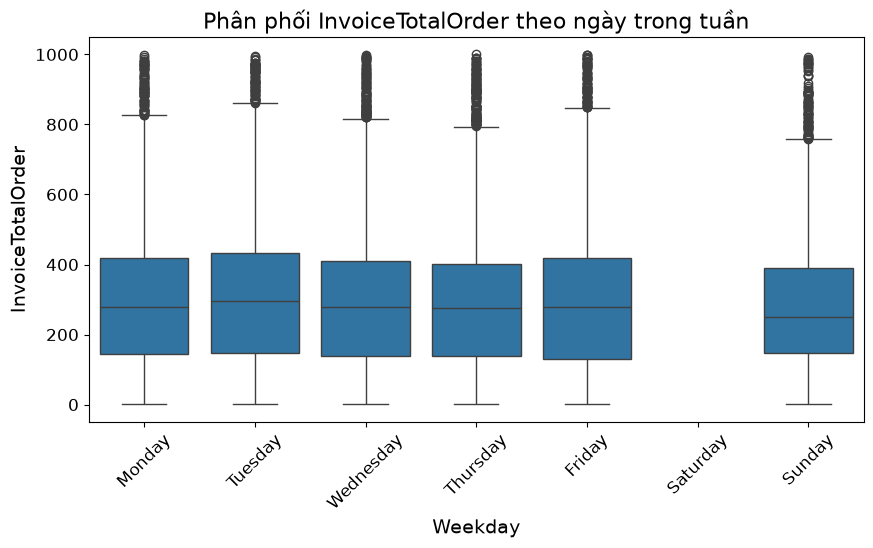

In [42]:
#Kiểm tra Weekday
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_summary = (
    df_invoice.groupby("Weekday")["InvoiceTotalOrder"]
    .agg(["count", "mean", "median", "std", "sum"])
    .reindex(weekday_order)
)

display(weekday_summary)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_invoice[df_invoice["InvoiceTotalOrder"] <= 1000],
    x="Weekday",
    y="InvoiceTotalOrder",
    order=weekday_order
)
plt.title("Phân phối InvoiceTotalOrder theo ngày trong tuần")
plt.xlabel("Weekday")
plt.ylabel("InvoiceTotalOrder")
plt.xticks(rotation=45)
plt.show()

Kiểm định t-test cho p-value rất nhỏ, cho thấy có sự khác biệt có ý nghĩa thống kê giữa nhóm ngày thường và nhóm cuối tuần về InvoiceTotalOrder.

Tuy nhiên, p-value nhỏ không có nghĩa là biến IsWeekend chắc chắn nên được giữ trong mô hình cuối. Cần kiểm tra thêm ý nghĩa kinh tế của hệ số, mô hình OLS đa biến, Adjusted R², AIC/BIC, RMSE và phần dư của mô hình.

,count,mean,median,std,sum
Month,,,,,
1,1086,635.19,305.87,"2,588.98","689,811.61"
2,1100,475.04,303.71,807.03,"522,545.56"
3,1454,492.58,298.06,"1,051.96","716,215.26"
4,1246,430.95,301.80,773.90,"536,968.49"
5,1681,457.64,305.45,814.31,"769,296.61"
6,1533,496.12,291.38,"1,450.00","760,547.01"
7,1475,486.83,303.29,869.55,"718,076.12"
8,1361,556.83,305.63,"1,340.38","757,841.38"
9,1837,575.09,325.50,"1,208.50","1,056,435.19"


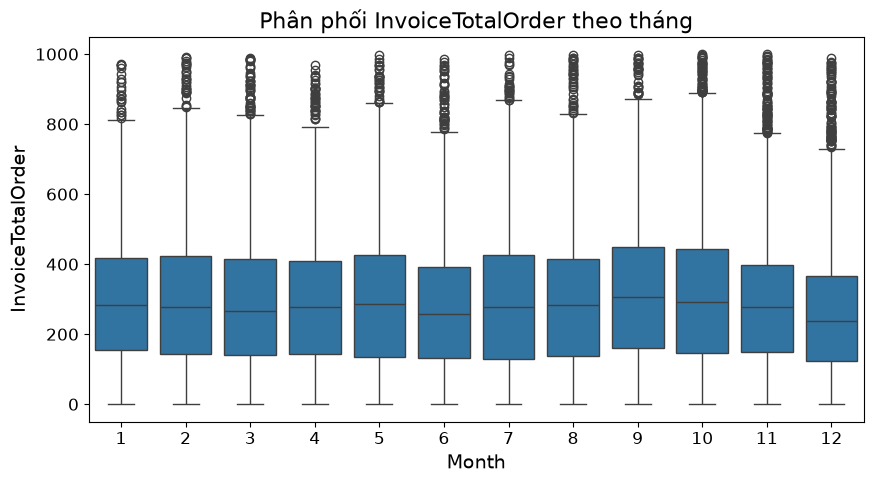

In [43]:
#Kiểm tra Month
month_summary = (
    df_invoice.groupby("Month")["InvoiceTotalOrder"]
    .agg(["count", "mean", "median", "std", "sum"])
)

display(month_summary)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_invoice[df_invoice["InvoiceTotalOrder"] <= 1000],
    x="Month",
    y="InvoiceTotalOrder"
)
plt.title("Phân phối InvoiceTotalOrder theo tháng")
plt.xlabel("Month")
plt.ylabel("InvoiceTotalOrder")
plt.show()

Phân tích theo tháng cho thấy giá trị hóa đơn và tổng doanh thu thay đổi theo thời gian, đặc biệt tăng mạnh ở các tháng cuối năm. Điều này gợi ý khả năng tồn tại yếu tố mùa vụ.

Tuy nhiên, Month chỉ nên được xem là biến ứng viên. Cần kiểm tra bằng mô hình hồi quy xem biến tháng có còn ý nghĩa khi đã kiểm soát các biến khác như số lượng sản phẩm, số dòng hóa đơn và đơn giá trung bình hay không.

,InvoiceTotalOrder,TotalQuantity,UniqueProducts,NumberOfRows,AvgUnitPrice,Month,Hour,IsWeekend
InvoiceTotalOrder,1.00,0.88,0.27,0.26,0.09,0.02,-0.00,-0.03
TotalQuantity,0.88,1.00,0.15,0.15,-0.01,0.00,-0.02,-0.03
UniqueProducts,0.27,0.15,1.00,1.00,-0.02,0.03,0.11,0.01
NumberOfRows,0.26,0.15,1.00,1.00,-0.02,0.03,0.11,0.01
AvgUnitPrice,0.09,-0.01,-0.02,-0.02,1.00,0.00,0.01,-0.01
Month,0.02,0.00,0.03,0.03,0.00,1.00,0.03,0.02
Hour,-0.00,-0.02,0.11,0.11,0.01,0.03,1.00,0.02
IsWeekend,-0.03,-0.03,0.01,0.01,-0.01,0.02,0.02,1.00


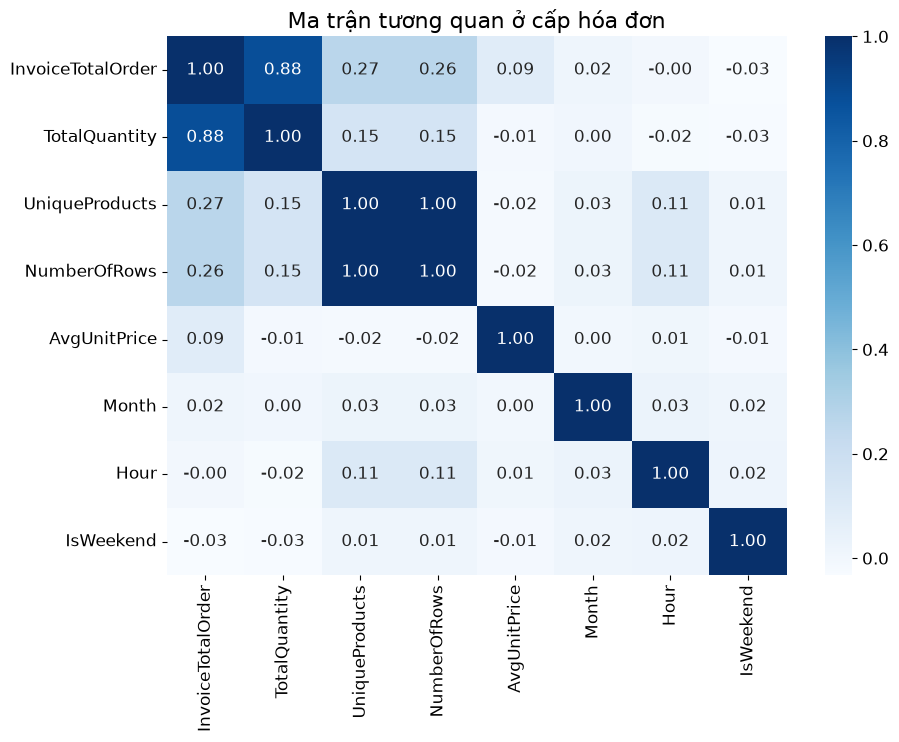

In [44]:
#
corr_cols = [
    "InvoiceTotalOrder",
    "TotalQuantity",
    "UniqueProducts",
    "NumberOfRows",
    "AvgUnitPrice",
    "Month",
    "Hour",
    "IsWeekend"
]

corr_matrix = df_invoice[corr_cols].corr()

display(corr_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Ma trận tương quan ở cấp hóa đơn")
plt.show()

Ma trận tương quan ở cấp hóa đơn cho thấy InvoiceTotalOrder có tương quan mạnh với TotalQuantity. Điều này hợp lý vì hóa đơn có tổng số lượng sản phẩm lớn thường có tổng giá trị cao hơn.

Tuy nhiên, cần cẩn thận vì InvoiceTotalOrder được tạo từ TotalOrder, mà TotalOrder = Quantity * UnitPrice. Do đó, một phần quan hệ giữa InvoiceTotalOrder, TotalQuantity và AvgUnitPrice là quan hệ cơ học. Khi diễn giải mô hình, không nên nói quá mạnh theo hướng quan hệ nhân quả.

In [45]:
feature_note = pd.DataFrame({
    "Feature": [
        "TotalOrder",
        "IsCancelled",
        "IsDiscount",
        "Month",
        "Weekday",
        "Hour",
        "IsWeekend",
        "InvoiceTotalOrder"
    ],
    "Created_from": [
        "Quantity * UnitPrice",
        "InvoiceNo starts with C",
        "StockCode = D or Description contains Discount",
        "InvoiceDate",
        "InvoiceDate",
        "InvoiceDate",
        "InvoiceDate",
        "Sum of TotalOrder by InvoiceNo"
    ],
    "Purpose": [
        "Business metric at transaction-line level",
        "Data cleaning flag",
        "Data cleaning flag",
        "Candidate predictor / EDA",
        "Candidate predictor / EDA",
        "Candidate predictor / EDA",
        "Candidate predictor / EDA",
        "Target candidate for linear regression"
    ],
    "Need_evaluation_before_final_model": [
        "Yes, if used as target or transformed",
        "No, if only used for filtering",
        "No, if only used for filtering",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ]
})

feature_note

,Feature,Created_from,Purpose,Need_evaluation_before_final_model
0,TotalOrder,Quantity * UnitPrice,Business metric at transaction-line level,"Yes, if used as target or transformed"
1,IsCancelled,InvoiceNo starts with C,Data cleaning flag,"No, if only used for filtering"
2,IsDiscount,StockCode = D or Description contains Discount,Data cleaning flag,"No, if only used for filtering"
3,Month,InvoiceDate,Candidate predictor / EDA,Yes
4,Weekday,InvoiceDate,Candidate predictor / EDA,Yes
5,Hour,InvoiceDate,Candidate predictor / EDA,Yes
6,IsWeekend,InvoiceDate,Candidate predictor / EDA,Yes
7,InvoiceTotalOrder,Sum of TotalOrder by InvoiceNo,Target candidate for linear regression,Yes
